# Detecção de fraudes em transações

**Professora:** Dra. Isadora Garcia Ferrão

In [7]:
import pandas as pd

url = "https://storage.googleapis.com/download.tensorflow.org/data/creditcard.csv"

df = pd.read_csv(url)

df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


## Problema de classificação desbalanceada

Fraudes são raras -> modelo pode ignorar a classe 1.

In [13]:
df["Class"].value_counts(normalize=True)

Class
0    0.998273
1    0.001727
Name: proportion, dtype: float64

In [14]:
#!pip install numpy

## Feature Enginneering 

Criando variáveis que ajudam o modelo.

In [15]:
import numpy as np 
df["Amount_log"] = np.log1p(df["Amount"])

In [16]:
from sklearn.preprocessing import StandardScaler
scaler =StandardScaler()
df["Amount_log"] = scaler.fit_transform(df[["Amount"]])

In [21]:
from sklearn.model_selection import train_test_split

x = df.drop("Class", axis=1)
y = df["Class"]


x_train, x_test, y_train, y_test = train_test_split(
    x, y, stratify=y, test_size=0.3, random_state=42
)

## Logistic Regression

In [22]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression(max_iter=1000)
model.fit(x_train,y_train)
y_pred= model.predict(x_test)

/home/diegosalvador/Projetos/CLI/.venv/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [ ]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))
# 0 tranzações normais 
# 1 tranzações fraudulentas 

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     85295
           1       0.87      0.66      0.75       148

    accuracy                           1.00     85443
   macro avg       0.93      0.83      0.88     85443
weighted avg       1.00      1.00      1.00     85443



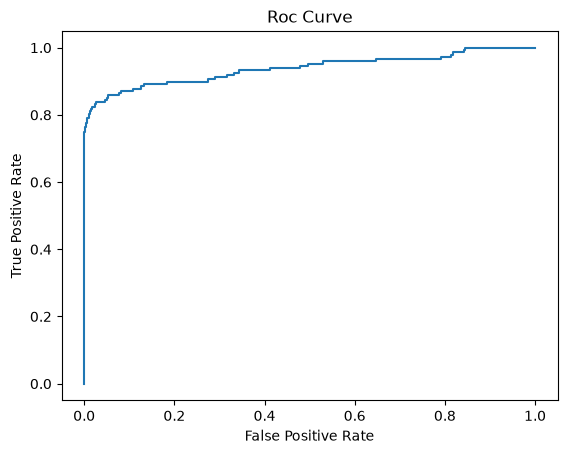

AUC 0.9375170909229178


In [24]:
from sklearn.metrics import roc_auc_score, roc_curve
import matplotlib.pyplot as plt 

y_probs = model.predict_proba(x_test)[:,1]

fpr, tpr, _= roc_curve(y_test,y_probs)

plt.plot(fpr, tpr)
plt.title("Roc Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.show()

print("AUC", roc_auc_score(y_test,y_probs))


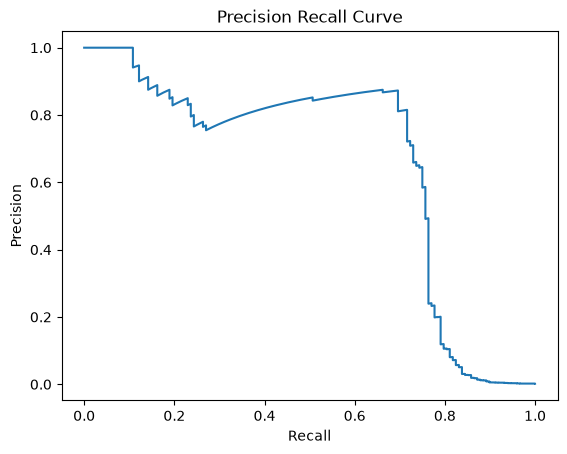

In [25]:
from sklearn.metrics import precision_recall_curve

precision, recall, _ = precision_recall_curve(y_test, y_probs)

plt.plot(recall, precision)
plt.title("Precision Recall Curve")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.show()


In [27]:
# UNDERSAMPLING
fraudes = df[df["Class"] == 1 ]
normais = df[df["Class"] == 0 ].sample(len(fraudes),random_state=42)

df_under =pd.concat([fraudes,normais])

In [29]:
#OVERSAMPLIG
from imblearn.over_sampling import  SMOTE

smote = SMOTE()

x_res, y_res = smote.fit_resample(x,y)


In [ ]:
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(


)

## Pré-processamento, Balanceamento e Treinamento

Como a base de dados é extremamente desbalanceada, um modelo simples aprenderia a prever apenas a classe 0 (normal) e acertaria 99.8% das vezes, mas falharia em encontrar as fraudes. Vamos separar os dados e usar a técnica **SMOTE (Synthetic Minority Over-sampling Technique)** para criar amostras sintéticas da classe minoritária (fraudes) apenas no conjunto de treino.

In [ ]:
# Instale as bibliotecas necessárias para rodar o modelo se não estiverem instaladas
#!pip install scikit-learn imbalanced-learn

In [11]:
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE

# Separando as variáveis independentes (X) e o alvo (y)
X = df.drop(["Class"], axis=1)
y = df["Class"]

# Divisão em Treino e Teste (80% treino, 20% teste)
# A estratificação garante que a proporção de fraudes se mantenha a mesma nos dois blocos.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("Proporção de Fraudes no Treino ANTES do SMOTE:")
print(y_train.value_counts())

# Aplicando o SMOTE apenas no conjunto de treinamento para não contaminar o teste com dados sintéticos
smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print("\nProporção de Fraudes no Treino APÓS o SMOTE (Agoram estão iguais!):")
print(y_train_sm.value_counts())

Proporção de Fraudes no Treino ANTES do SMOTE:
Class
0    227451
1       394
Name: count, dtype: int64

Proporção de Fraudes no Treino APÓS o SMOTE (Agoram estão iguais!):
Class
0    227451
1    227451
Name: count, dtype: int64


In [12]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

# Treinando o modelo (Random Forest)
# Limitamos para 50 estimadores para rodar de maneira mais veloz.
rf_model = RandomForestClassifier(random_state=42, n_estimators=50, n_jobs=-1)
rf_model.fit(X_train_sm, y_train_sm)

# Avaliando o modelo no conjunto de TESTE (que contem apenas dados reais, não mexidos)
y_pred = rf_model.predict(X_test)

print("Relatório de Classificação:\n")
print(classification_report(y_test, y_pred))

print("\nMatriz de Confusão:\n")
print(confusion_matrix(y_test, y_pred))

# O recall na classe 1 e a f1-score são métricas chaves aqui para avaliar os acertos em fraudes!

Relatório de Classificação:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.84      0.85      0.84        98

    accuracy                           1.00     56962
   macro avg       0.92      0.92      0.92     56962
weighted avg       1.00      1.00      1.00     56962


Matriz de Confusão:

[[56848    16]
 [   15    83]]
